# 01 | Exploracao e validacao dos dados

Objetivo: construir uma primeira leitura confiavel da base de inadimplencia habitacional da CAIXA antes de qualquer modelagem.

Fluxo da analise:

1. Configurar caminhos e carregar dados.
2. Entender estrutura, tipos e granularidade.
3. Validar chaves, ausencias e duplicidades.
4. Construir a taxa mensal de inadimplencia.
5. Criar o alvo preliminar em nivel de contrato.
6. Explorar inadimplencia por segmentos.
7. Relacionar visualmente inadimplencia e indicadores macro.


## Setup

Importacao de bibliotecas, definicao de caminhos e criacao das pastas de saida usadas pelo notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent

DATA_PATH = PROJECT_DIR / 'data' / 'raw' / 'desafio_inadimplencia_caixa.xlsx'
OUTPUT_TABLES = PROJECT_DIR / 'outputs' / 'tables'
OUTPUT_FIGURES = PROJECT_DIR / 'outputs' / 'figures'

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

DATA_PATH

PosixPath('/home/mateus/desafio-inadimplencia/data/raw/desafio_inadimplencia_caixa.xlsx')

## Carregamento dos dados

Leitura das tres abas do arquivo Excel e padronizacao das colunas de data. A base original permanece em `data/raw/`.

In [2]:
df_contratos = pd.read_excel(DATA_PATH, sheet_name='contratos')
df_parcelas = pd.read_excel(DATA_PATH, sheet_name='parcelas')
df_macro = pd.read_excel(DATA_PATH, sheet_name='indicadores_macro')

for df in [df_contratos, df_parcelas, df_macro]:
    for col in df.columns:
        if col.startswith('dt_'):
            df[col] = pd.to_datetime(df[col])

df_contratos.shape, df_parcelas.shape, df_macro.shape

((10000, 12), (213701, 7), (36, 6))

## 1. Visao geral das tabelas

In [3]:
def dataset_overview(name, df):
    date_cols = [col for col in df.columns if pd.api.types.is_datetime64_any_dtype(df[col])]
    return {
        'tabela': name,
        'linhas': len(df),
        'colunas': df.shape[1],
        'colunas_data': ', '.join(date_cols),
        'data_min': min([df[col].min() for col in date_cols], default=pd.NaT),
        'data_max': max([df[col].max() for col in date_cols], default=pd.NaT),
    }

overview = pd.DataFrame([
    dataset_overview('contratos', df_contratos),
    dataset_overview('parcelas', df_parcelas),
    dataset_overview('indicadores_macro', df_macro),
])

overview

,tabela,linhas,colunas,colunas_data,data_min,data_max
0,contratos,10000,12,dt_contratacao,2022-01-01,2024-02-26
1,parcelas,213701,7,dt_referencia,2022-02-01,2024-12-01
2,indicadores_macro,36,6,dt_referencia,2022-01-01,2024-12-01


In [4]:
columns = pd.concat(
    [
        pd.DataFrame({'tabela': name, 'coluna': df.columns, 'dtype': [str(dtype) for dtype in df.dtypes]})
        for name, df in [('contratos', df_contratos), ('parcelas', df_parcelas), ('indicadores_macro', df_macro)]
    ],
    ignore_index=True,
)

columns

,tabela,coluna,dtype
0,contratos,id_contrato,int64
1,contratos,dt_contratacao,datetime64[us]
2,contratos,vr_financiado,float64
3,contratos,vr_entrada,float64
4,contratos,tx_juros_anual,float64
5,contratos,prazo_meses,int64
6,contratos,faixa_renda,str
7,contratos,uf,str
8,contratos,tipo_imovel,str
9,contratos,programa_social,str


## 2. Validacao basica: chaves, datas, ausencias e duplicidades

In [5]:
missing_summary = pd.concat(
    [
        df.isna().sum().rename('missing').to_frame()
        .assign(tabela=name, pct_missing=lambda x: x['missing'] / len(df))
        .reset_index(names='coluna')
        for name, df in [('contratos', df_contratos), ('parcelas', df_parcelas), ('indicadores_macro', df_macro)]
    ],
    ignore_index=True,
)[['tabela', 'coluna', 'missing', 'pct_missing']]

missing_summary.sort_values(['pct_missing', 'missing'], ascending=False).head(30)

,tabela,coluna,missing,pct_missing
0,contratos,id_contrato,0,0.0000
1,contratos,dt_contratacao,0,0.0000
2,contratos,vr_financiado,0,0.0000
3,contratos,vr_entrada,0,0.0000
4,contratos,tx_juros_anual,0,0.0000
5,contratos,prazo_meses,0,0.0000
6,contratos,faixa_renda,0,0.0000
7,contratos,uf,0,0.0000
8,contratos,tipo_imovel,0,0.0000
9,contratos,programa_social,0,0.0000


In [6]:
duplicate_checks = pd.DataFrame([
    {
        'tabela': 'contratos',
        'chave': 'id_contrato',
        'duplicatas': df_contratos.duplicated(['id_contrato']).sum(),
    },
    {
        'tabela': 'parcelas',
        'chave': 'id_contrato + dt_referencia',
        'duplicatas': df_parcelas.duplicated(['id_contrato', 'dt_referencia']).sum(),
    },
    {
        'tabela': 'indicadores_macro',
        'chave': 'dt_referencia',
        'duplicatas': df_macro.duplicated(['dt_referencia']).sum(),
    },
])

duplicate_checks

,tabela,chave,duplicatas
0,contratos,id_contrato,0
1,parcelas,id_contrato + dt_referencia,0
2,indicadores_macro,dt_referencia,0


In [7]:
contract_ids = set(df_contratos['id_contrato'])
parcel_contract_ids = set(df_parcelas['id_contrato'])

key_integrity = pd.DataFrame([
    {'checagem': 'contratos_sem_parcela', 'qtd': len(contract_ids - parcel_contract_ids)},
    {'checagem': 'parcelas_sem_contrato', 'qtd': len(parcel_contract_ids - contract_ids)},
])

key_integrity

,checagem,qtd
0,contratos_sem_parcela,0
1,parcelas_sem_contrato,0


## 3. Taxa mensal de inadimplencia

In [8]:
monthly_delinquency = (
    df_parcelas
    .groupby('dt_referencia', as_index=False)
    .agg(
        contratos_ativos=('id_contrato', 'nunique'),
        parcelas_observadas=('id_contrato', 'size'),
        contratos_inadimplentes=('fl_inadimplente', 'sum'),
        taxa_inadimplencia=('fl_inadimplente', 'mean'),
        dias_atraso_medio=('dias_atraso', 'mean'),
        saldo_devedor_total=('saldo_devedor', 'sum'),
    )
    .sort_values('dt_referencia')
)

monthly_delinquency.head()

,dt_referencia,contratos_ativos,parcelas_observadas,contratos_inadimplentes,taxa_inadimplencia,dias_atraso_medio,saldo_devedor_total
0,2022-02-01,351,351,11,0.0313,9.5499,"70,319,080.0600"
1,2022-03-01,682,682,28,0.0411,10.2111,"136,458,769.9900"
2,2022-04-01,1000,1000,46,0.0460,10.8270,"199,194,808.5300"
3,2022-05-01,1299,1299,50,0.0385,10.4919,"259,905,268.6500"
4,2022-06-01,1610,1610,84,0.0522,12.2540,"322,369,588.4700"


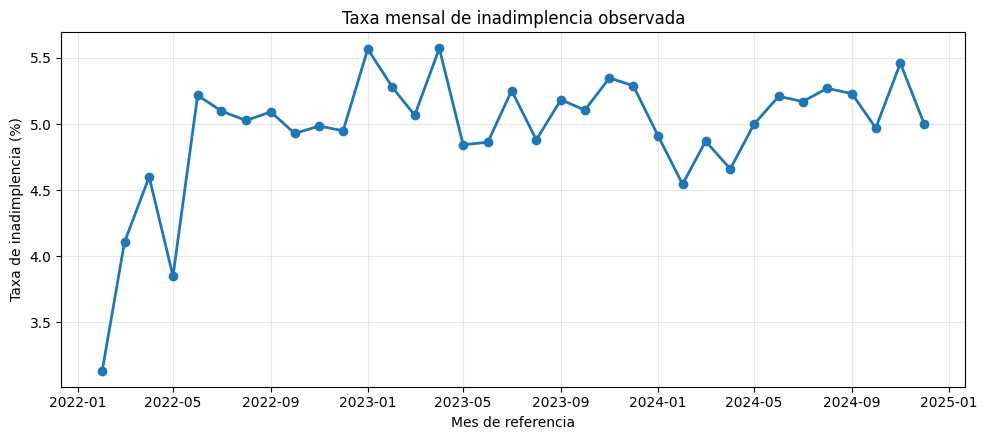

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly_delinquency['dt_referencia'], monthly_delinquency['taxa_inadimplencia'] * 100, marker='o', linewidth=2)
ax.set_title('Taxa mensal de inadimplencia observada')
ax.set_xlabel('Mes de referencia')
ax.set_ylabel('Taxa de inadimplencia (%)')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / 'monthly_delinquency_rate.png', dpi=160)
plt.show()

## 4. Alvo preliminar em nivel de contrato

In [10]:
contract_target = (
    df_parcelas
    .groupby('id_contrato', as_index=False)
    .agg(
        fl_ever_inadimplente=('fl_inadimplente', 'max'),
        qtd_meses_observados=('dt_referencia', 'nunique'),
        max_dias_atraso=('dias_atraso', 'max'),
        primeiro_mes_observado=('dt_referencia', 'min'),
        ultimo_mes_observado=('dt_referencia', 'max'),
    )
)

df_contratos_modelo = df_contratos.merge(contract_target, on='id_contrato', how='left')
df_contratos_modelo['fl_ever_inadimplente'] = df_contratos_modelo['fl_ever_inadimplente'].fillna(0).astype(int)

df_contratos_modelo.to_csv(OUTPUT_TABLES / 'contract_level_target_preview.csv', index=False)

pd.DataFrame([
    {'metrica': 'contratos', 'valor': len(df_contratos_modelo)},
    {'metrica': 'contratos_ever_inadimplentes', 'valor': df_contratos_modelo['fl_ever_inadimplente'].sum()},
])

,metrica,valor
0,contratos,10000
1,contratos_ever_inadimplentes,5260


## 5. Segmentacao descritiva de risco

Construcao da tabela numerica de inadimplencia por segmentos do contrato. Variaveis continuas sao agrupadas em faixas de igual amplitude para leitura exploratoria.

In [11]:
def make_equal_width_bins(series, bins=6, precision=2):
    """Create business-readable equal-width ranges from observed min/max."""
    clean = series.dropna()
    if clean.empty:
        return pd.Series(pd.NA, index=series.index, dtype="object")

    min_value = clean.min()
    max_value = clean.max()
    if min_value == max_value:
        label = f"{min_value:.{precision}f}"
        return pd.Series(label, index=series.index, dtype="object")

    edges = np.linspace(min_value, max_value, bins + 1)
    labels = [
        f"{edges[i]:.{precision}f}-{edges[i + 1]:.{precision}f}"
        for i in range(len(edges) - 1)
    ]
    cut = pd.cut(series, bins=edges, labels=labels, include_lowest=True)

    return cut.astype("object")


df_segmentacao = df_contratos_modelo.copy()
df_segmentacao["prazo_meses_cat"] = df_segmentacao["prazo_meses"].astype("Int64").astype(str) + " meses"
df_segmentacao["tx_juros_anual_faixa"] = make_equal_width_bins(df_segmentacao["tx_juros_anual"], bins=6, precision=2)
df_segmentacao["score_credito_contratacao_faixa"] = make_equal_width_bins(
    df_segmentacao["score_credito_contratacao"], bins=6, precision=0
)
df_segmentacao["ltv_faixa"] = make_equal_width_bins(df_segmentacao["ltv"], bins=6, precision=2)

segment_cols = [
    "faixa_renda",
    "uf",
    "tipo_imovel",
    "programa_social",
    "prazo_meses_cat",
    "tx_juros_anual_faixa",
    "score_credito_contratacao_faixa",
    "ltv_faixa",
]

segment_summaries = []

for col in segment_cols:
    if col in df_segmentacao.columns:
        summary = (
            df_segmentacao
            .groupby(col, dropna=False)
            .agg(
                contratos=("id_contrato", "count"),
                taxa_ever_inadimplente=("fl_ever_inadimplente", "mean"),
                score_medio=("score_credito_contratacao", "mean"),
                ltv_medio=("ltv", "mean"),
                tx_juros_anual_media=("tx_juros_anual", "mean"),
                prazo_meses_medio=("prazo_meses", "mean"),
            )
            .reset_index()
            .assign(segmento=col)
            .rename(columns={col: "categoria"})
        )
        segment_summaries.append(summary)

segment_summary = pd.concat(segment_summaries, ignore_index=True)
segment_summary.to_csv(OUTPUT_TABLES / "eda_segment_delinquency_summary.csv", index=False)
segment_summary.sort_values("taxa_ever_inadimplente", ascending=False).head(20)

,categoria,contratos,taxa_ever_inadimplente,score_medio,ltv_medio,tx_juros_anual_media,prazo_meses_medio,segmento
25,RR,52,0.6731,615.5577,83.0613,7.6450,291.9231,uf
48,400-500,685,0.6292,465.9314,86.5335,6.8694,269.7810,score_credito_contratacao_faixa
47,300-400,40,0.6250,367.9750,86.7308,6.9253,250.5000,score_credito_contratacao_faixa
15,MS,157,0.6178,651.4904,82.9668,7.7403,274.7771,uf
3,Até 3 SM,3437,0.6049,581.8665,87.4801,6.7094,270.6721,faixa_renda
58,86.67-90.00,2860,0.5930,593.6056,88.1371,6.8703,272.7902,ltv_faixa
49,500-600,2658,0.5839,558.6343,85.6624,7.2168,270.9932,score_credito_contratacao_faixa
28,SE,102,0.5784,657.3137,83.5218,7.7099,270.0000,uf
17,PA,269,0.5613,640.9219,83.8254,7.5728,263.4201,uf
57,83.33-86.67,3051,0.5598,623.9613,85.2119,7.4303,270.6588,ltv_faixa


## 6. Visualizacao dos segmentos de risco

A tabela numerica acima permanece como base auditavel. O grafico abaixo transforma a mesma informacao em uma leitura visual de risco por segmento, destacando a taxa de contratos que ficaram inadimplentes ao menos uma vez na janela observada.


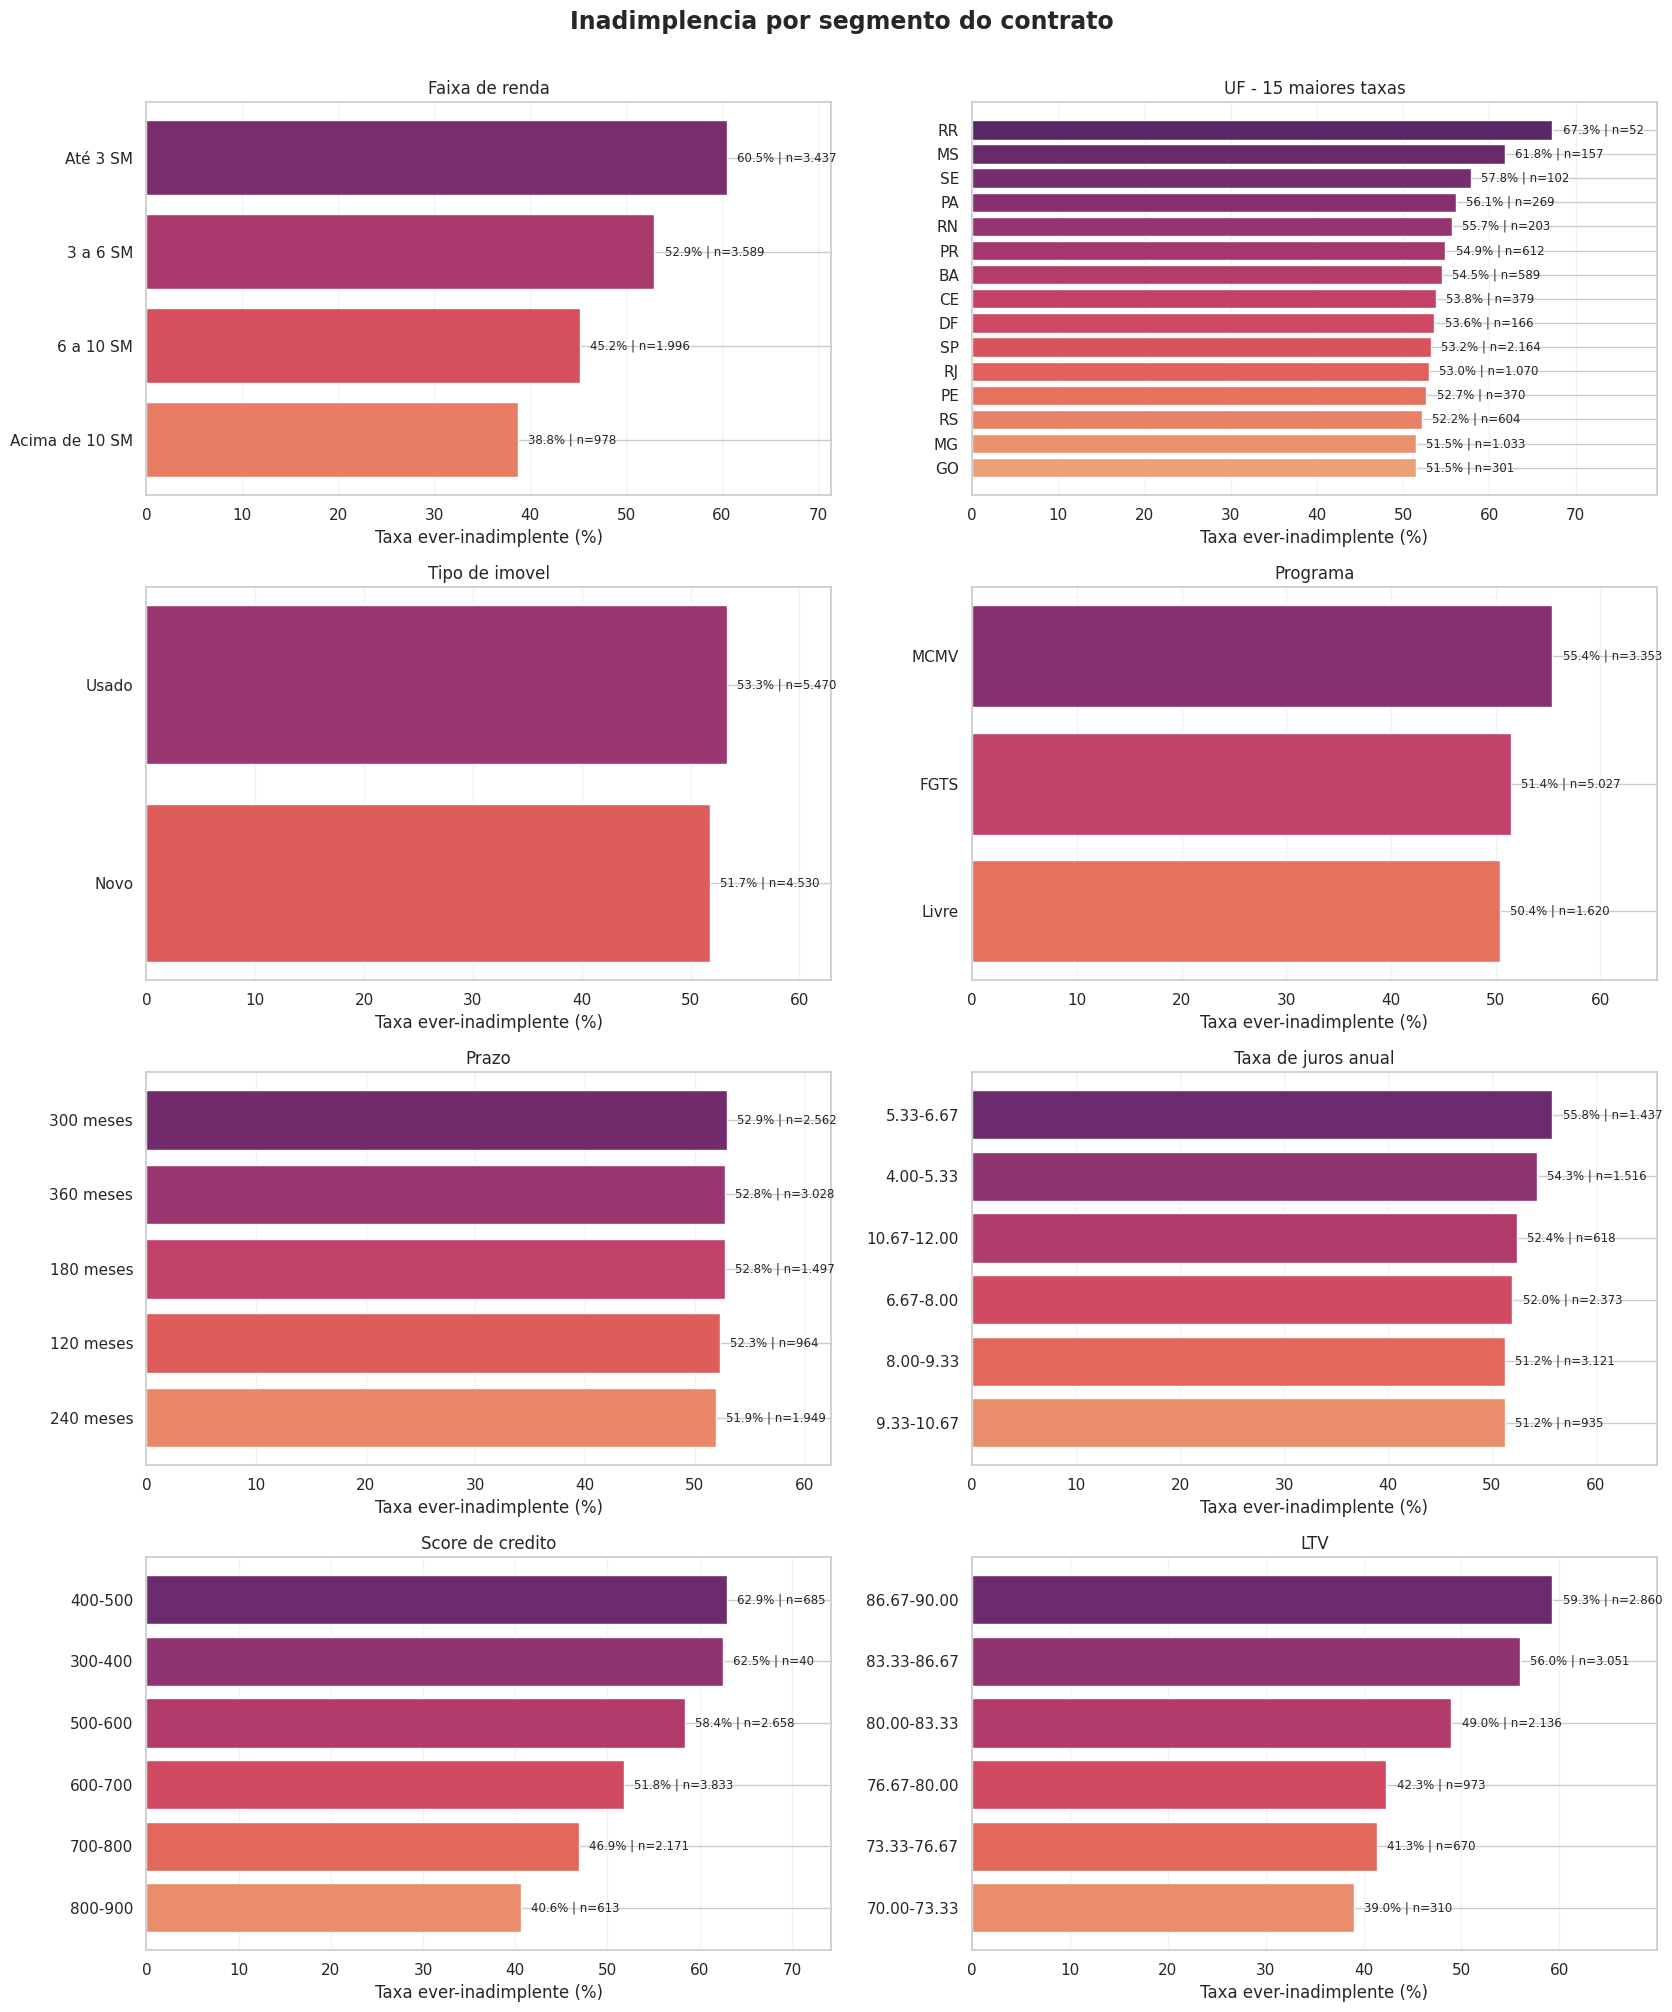

In [12]:
sns.set_theme(style="whitegrid", context="notebook")

segment_labels = {
    "faixa_renda": "Faixa de renda",
    "uf": "UF",
    "tipo_imovel": "Tipo de imovel",
    "programa_social": "Programa",
    "prazo_meses_cat": "Prazo",
    "tx_juros_anual_faixa": "Taxa de juros anual",
    "score_credito_contratacao_faixa": "Score de credito",
    "ltv_faixa": "LTV",
}

plot_data = segment_summary.copy()
plot_data["categoria"] = plot_data["categoria"].astype(str)
plot_data["taxa_pct"] = plot_data["taxa_ever_inadimplente"] * 100

fig, axes = plt.subplots(4, 2, figsize=(17, 20))
axes = axes.flatten()

for ax, segmento in zip(axes, segment_cols):
    subset = plot_data.loc[plot_data["segmento"] == segmento].copy()

    if segmento == "uf" and len(subset) > 15:
        subset = subset.nlargest(15, "taxa_ever_inadimplente")
        title_suffix = " - 15 maiores taxas"
    else:
        subset = subset.sort_values("taxa_ever_inadimplente", ascending=False)
        title_suffix = ""

    subset = subset.sort_values("taxa_ever_inadimplente", ascending=True)

    colors = sns.color_palette("flare", n_colors=len(subset))
    ax.barh(subset["categoria"], subset["taxa_pct"], color=colors)
    ax.set_title(f"{segment_labels.get(segmento, segmento)}{title_suffix}")
    ax.set_xlabel("Taxa ever-inadimplente (%)")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)

    x_max = max(subset["taxa_pct"].max() * 1.18, 1)
    ax.set_xlim(0, x_max)

    for y, (_, row) in enumerate(subset.iterrows()):
        label = f"{row['taxa_pct']:.1f}% | n={int(row['contratos']):,}".replace(",", ".")
        ax.text(row["taxa_pct"] + x_max * 0.015, y, label, va="center", fontsize=8.5)

for ax in axes[len(segment_cols):]:
    ax.axis("off")

fig.suptitle("Inadimplencia por segmento do contrato", fontsize=17, fontweight="bold", y=1.005)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / "segment_delinquency_rates.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Indicadores macroeconomicos

In [13]:
df_macro_summary = df_macro.describe(include='all').transpose()
df_macro_summary

,count,mean,min,25%,50%,75%,max,std
dt_referencia,36,2023-06-16 18:40:00,2022-01-01 00:00:00,2022-09-23 12:00:00,2023-06-16 00:00:00,2024-03-08 18:00:00,2024-12-01 00:00:00,NaN
selic_12m,36.0000,12.2142,9.2700,11.1300,12.4700,13.2475,13.8300,1.3018
ipca_12m,36.0000,7.4861,4.6500,5.9400,7.6350,8.7875,10.5600,1.7372
tx_desemprego_12m,36.0000,8.9272,6.6800,8.1025,8.7450,9.8975,11.7100,1.4147
rendimento_medio,36.0000,"2,999.6714","2,766.7700","2,889.0600","3,000.2050","3,106.9025","3,223.6900",132.1718
confianca_consumidor,36.0000,92.3197,81.8700,85.8075,92.6700,97.6700,106.0800,6.2614


In [14]:
macro_with_delinquency = monthly_delinquency.merge(df_macro, on='dt_referencia', how='left')
macro_with_delinquency.to_csv(OUTPUT_TABLES / 'monthly_delinquency_with_macro.csv', index=False)

macro_with_delinquency.tail(12)

,dt_referencia,contratos_ativos,parcelas_observadas,contratos_inadimplentes,taxa_inadimplencia,dias_atraso_medio,saldo_devedor_total,selic_12m,ipca_12m,tx_desemprego_12m,rendimento_medio,confianca_consumidor
23,2024-01-01,8997,8997,442,0.0491,11.8730,"1,769,717,657.7100",11.7200,6.2400,8.5300,"3,060.4700",96.7500
24,2024-02-01,9550,9550,434,0.0454,11.3773,"1,879,751,048.3400",11.2600,6.1600,8.5000,"3,103.7600",98.2800
25,2024-03-01,10000,10000,487,0.0487,12.0772,"1,971,491,319.0300",11.1900,5.7100,8.2300,"3,088.4700",99.4900
26,2024-04-01,10000,10000,466,0.0466,11.6644,"1,969,083,131.9000",10.7700,5.5100,7.8700,"3,150.4300",99.8800
27,2024-05-01,10000,10000,500,0.0500,11.7512,"1,966,707,622.4000",10.4700,5.9400,7.3700,"3,116.3300",100.2400
28,2024-06-01,10000,10000,521,0.0521,12.1498,"1,964,380,666.0800",10.4900,5.9400,7.2900,"3,138.1300",99.4400
29,2024-07-01,10000,10000,517,0.0517,11.9893,"1,962,042,346.5300",10.4700,5.3400,6.9800,"3,173.4100",97.8200
30,2024-08-01,10000,10000,527,0.0527,12.3654,"1,959,699,646.6600",10.8400,5.4900,6.6800,"3,145.1000",97.6200
31,2024-09-01,10000,10000,523,0.0523,12.4338,"1,957,328,078.5200",10.7500,5.1200,6.7500,"3,186.8300",96.3100
32,2024-10-01,10000,10000,497,0.0497,11.8634,"1,954,894,478.1000",10.9500,4.6500,6.9100,"3,221.0000",99.5200


## 8. Taxa de inadimplencia e indicadores macro

Como a taxa de inadimplencia e os indicadores macroeconomicos estao em escalas diferentes, o grafico abaixo padroniza todas as series em z-score. Assim, conseguimos comparar visualmente direcao, defasagens e possiveis co-movimentos sem misturar unidades.


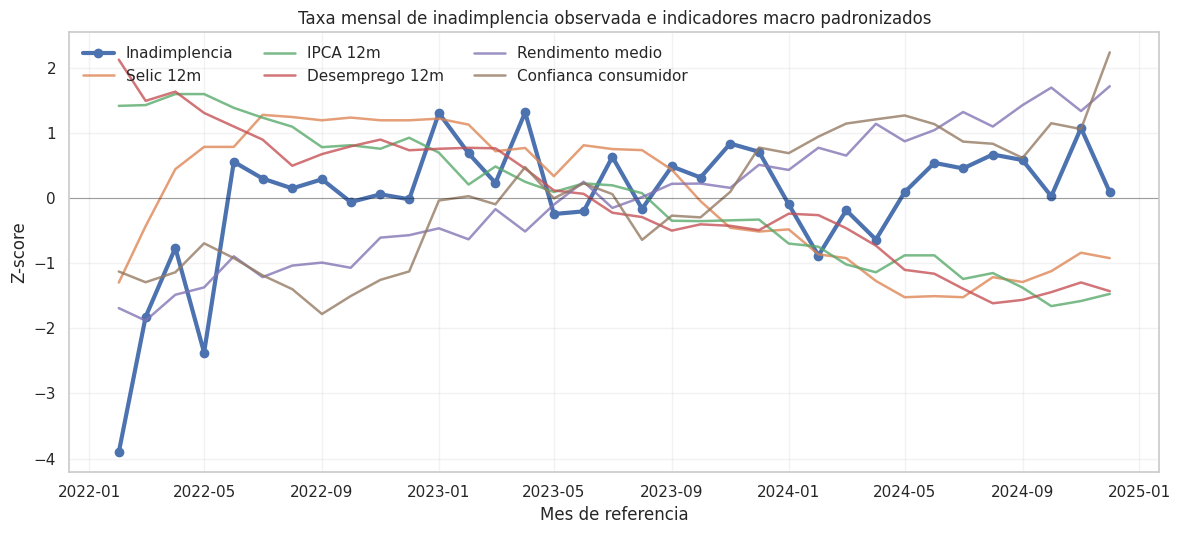

,indicador,correlacao_com_taxa_inadimplencia
0,selic_12m,0.1609
1,ipca_12m,-0.3951
2,tx_desemprego_12m,-0.4932
3,rendimento_medio,0.4236
4,confianca_consumidor,0.2954


In [15]:
macro_cols = [
    'selic_12m',
    'ipca_12m',
    'tx_desemprego_12m',
    'rendimento_medio',
    'confianca_consumidor',
]

macro_plot_cols = ['taxa_inadimplencia'] + [col for col in macro_cols if col in macro_with_delinquency.columns]
macro_plot = macro_with_delinquency[['dt_referencia'] + macro_plot_cols].dropna().copy()

zscore_plot = macro_plot[['dt_referencia']].copy()
for col in macro_plot_cols:
    std = macro_plot[col].std(ddof=0)
    zscore_plot[col] = 0 if std == 0 else (macro_plot[col] - macro_plot[col].mean()) / std

macro_labels = {
    'taxa_inadimplencia': 'Inadimplencia',
    'selic_12m': 'Selic 12m',
    'ipca_12m': 'IPCA 12m',
    'tx_desemprego_12m': 'Desemprego 12m',
    'rendimento_medio': 'Rendimento medio',
    'confianca_consumidor': 'Confianca consumidor',
}

fig, ax = plt.subplots(figsize=(12, 5.5))
for col in macro_plot_cols:
    linewidth = 3 if col == 'taxa_inadimplencia' else 1.8
    alpha = 1.0 if col == 'taxa_inadimplencia' else 0.78
    ax.plot(
        zscore_plot['dt_referencia'],
        zscore_plot[col],
        marker='o' if col == 'taxa_inadimplencia' else None,
        linewidth=linewidth,
        alpha=alpha,
        label=macro_labels.get(col, col),
    )

ax.axhline(0, color='black', linewidth=0.8, alpha=0.35)
ax.set_title('Taxa mensal de inadimplencia observada e indicadores macro padronizados')
ax.set_xlabel('Mes de referencia')
ax.set_ylabel('Z-score')
ax.grid(True, alpha=0.25)
ax.legend(ncol=3, frameon=False, loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / 'monthly_delinquency_macro_zscore.png', dpi=180, bbox_inches='tight')
plt.show()

macro_correlations = (
    macro_plot[macro_plot_cols]
    .corr()
    .loc[macro_plot_cols[1:], ['taxa_inadimplencia']]
    .rename(columns={'taxa_inadimplencia': 'correlacao_com_taxa_inadimplencia'})
    .reset_index(names='indicador')
)
macro_correlations.to_csv(OUTPUT_TABLES / 'eda_macro_delinquency_correlations.csv', index=False)
macro_correlations
